# 05_Data Visualization I

# Data Visualization I

Data를 숫자로만 확인하면 Data의 전체적인 모습을 파악하기 어렵다.

Data Visualization을 이용하면 다음과 같은 특징을 쉽게 발견할 수 있다.

- 값이 주로 어디에 분포하는가?
- Data가 넓게 퍼져 있는가?
- 한쪽으로 치우쳐 있는가?
- 매우 크거나 작은 값이 존재하는가?
- Category별 Sample의 수는 어떻게 다른가?

이번 강의에서는 Data의 분포를 이해하기 위해 다음 세 가지 Plot을 사용한다.

- Histogram
- Box Plot
- Bar Plot

> Data → Visualization → Pattern Discovery

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# California Housing Data 읽기
df = pd.read_csv(data_path+"california_housing.csv")

# Data 확인
display(df.head())

# Data의 크기와 Column 확인
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## Why Visualization?

Mean, Median, Standard Deviation과 같은 Statistics는 Data를 몇 개의 숫자로 요약한다.

하지만 같은 Mean을 가지는 Data라도 실제 분포의 모습은 매우 다를 수 있다.

따라서 Data를 분석할 때는 Statistics와 Visualization을 함께 사용하는 것이 좋다.

먼저 California Housing Data의 `MedInc`를 살펴보자.

`MedInc`는 지역의 Median Income을 나타낸다.

In [3]:
# MedInc의 기초통계 확인
print("Mean:", df["MedInc"].mean())
print("Median:", df["MedInc"].median())
print("Minimum:", df["MedInc"].min())
print("Maximum:", df["MedInc"].max())

Mean: 3.8706710029069766
Median: 3.5347999999999997
Minimum: 0.4999
Maximum: 15.0001


## Histogram

Histogram은 Numerical Variable의 값이 어떻게 분포되어 있는지를 보여준다.

전체 범위를 여러 Interval로 나누고 각 Interval에 포함되는 Sample의 수를 표시한다.

각 Interval을 Bin이라고 한다.

Histogram을 이용하면 다음을 관찰할 수 있다.

- Data가 많이 모여 있는 구간
- Data가 퍼져 있는 정도
- Distribution의 Shape
- Skewness
- Extreme Values

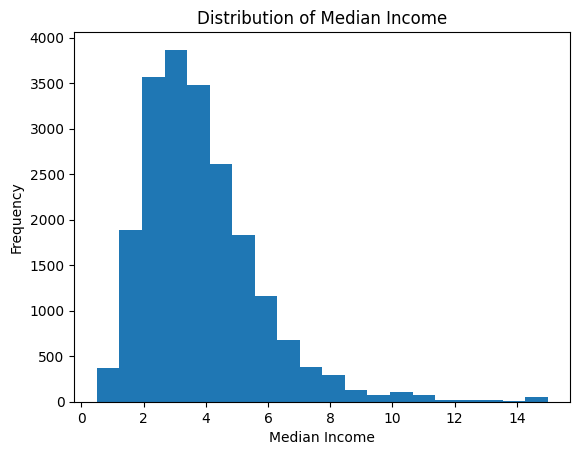

In [4]:
# MedInc의 Histogram
plt.hist(df["MedInc"], bins=20)

plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.title("Distribution of Median Income")

plt.show()

## Number of Bins

Histogram의 모습은 Bin의 수에 따라 달라진다.

Bin이 너무 적으면 Distribution의 세부적인 특징이 사라질 수 있다.

반대로 Bin이 너무 많으면 작은 변화가 지나치게 강조될 수 있다.

따라서 Histogram을 해석할 때는 Bin의 수도 고려해야 한다.

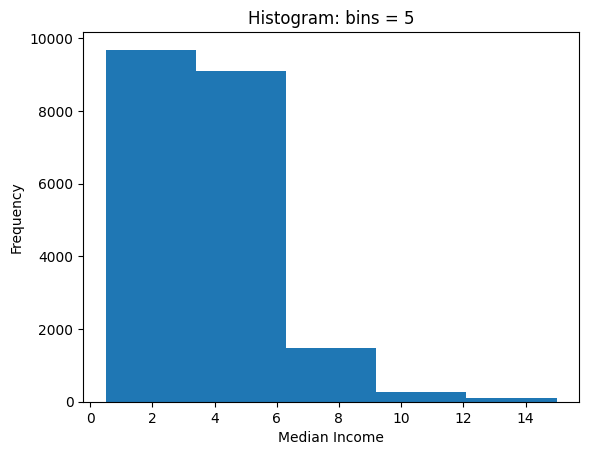

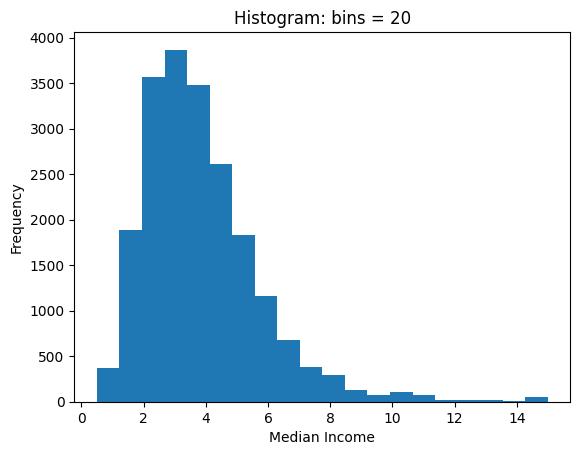

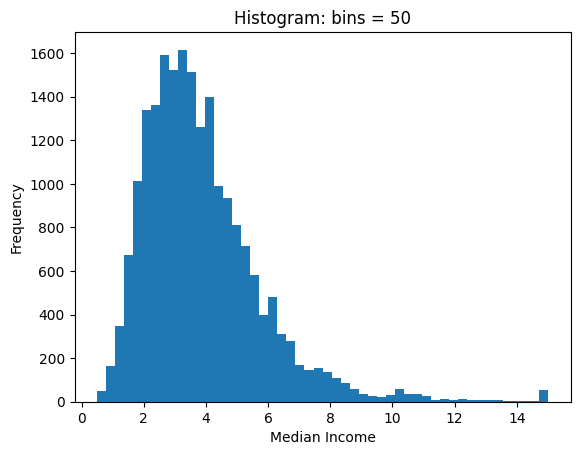

In [5]:
# 같은 Data를 서로 다른 Bin 수로 확인
for bins in [5, 20, 50]:
    plt.figure()
    plt.hist(df["MedInc"], bins=bins)

    plt.xlabel("Median Income")
    plt.ylabel("Frequency")
    plt.title(f"Histogram: bins = {bins}")

    plt.show()

## Distribution Shape

Histogram을 볼 때 단순히 가장 높은 막대만 보는 것이 아니다.

전체적인 Distribution의 Shape를 관찰해야 한다.

다음과 같은 질문을 생각할 수 있다.

- 값이 어느 구간에 가장 많이 모여 있는가?
- Distribution이 대칭적인가?
- 왼쪽이나 오른쪽으로 긴 Tail이 존재하는가?
- 다른 값들과 크게 떨어진 값이 존재하는가?

이러한 특징은 이후 어떤 Machine Learning Method를 사용할 것인지 판단할 때도 중요할 수 있다.

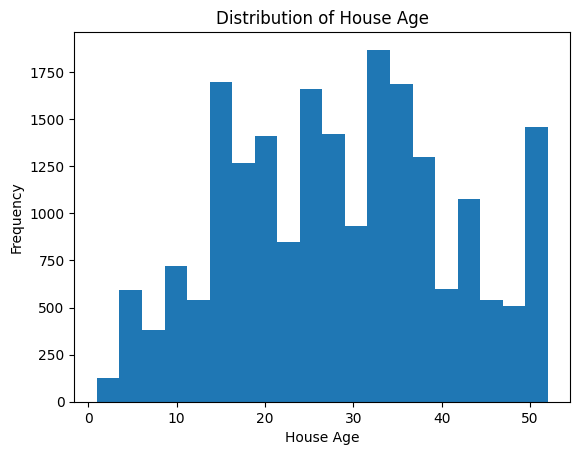

In [6]:
# HouseAge의 Distribution 확인
plt.hist(df["HouseAge"], bins=20)

plt.xlabel("House Age")
plt.ylabel("Frequency")
plt.title("Distribution of House Age")

plt.show()

## Box Plot

Histogram은 Distribution의 전체적인 Shape를 보여준다.

Box Plot은 Distribution을 보다 간결하게 요약한다.

Box Plot에서는 다음 값들이 중요하다.

- Median
- First Quartile $Q_1$
- Third Quartile $Q_3$
- Interquartile Range (IQR)

$$
IQR = Q_3-Q_1
$$

Box Plot을 이용하면 Data의 중심과 퍼짐뿐 아니라 Outlier 후보도 쉽게 발견할 수 있다.

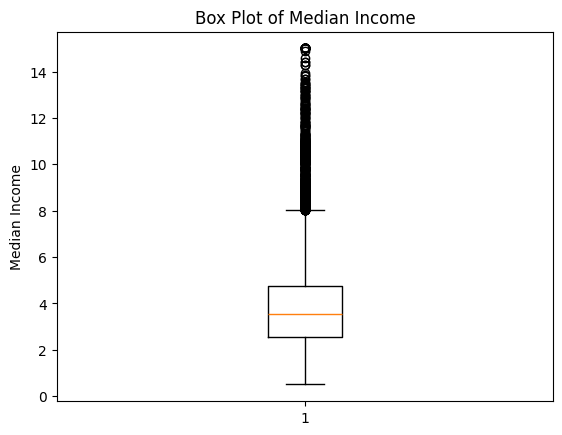

In [7]:
# MedInc의 Box Plot
plt.boxplot(df["MedInc"])

plt.ylabel("Median Income")
plt.title("Box Plot of Median Income")

plt.show()

## Histogram and Box Plot

Histogram과 Box Plot은 같은 Numerical Data를 서로 다른 관점에서 보여준다.

Histogram은 Distribution의 Shape를 자세히 보여준다.

Box Plot은 Distribution을 요약하고 Outlier를 빠르게 발견하는 데 유용하다.

따라서 두 Plot은 서로 대체하는 것이 아니라 함께 사용할 수 있다.

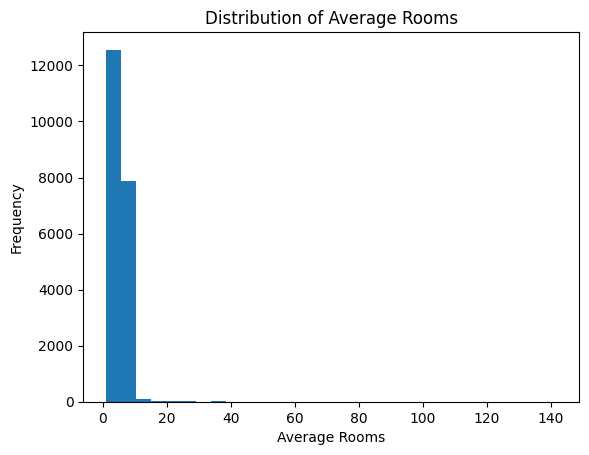

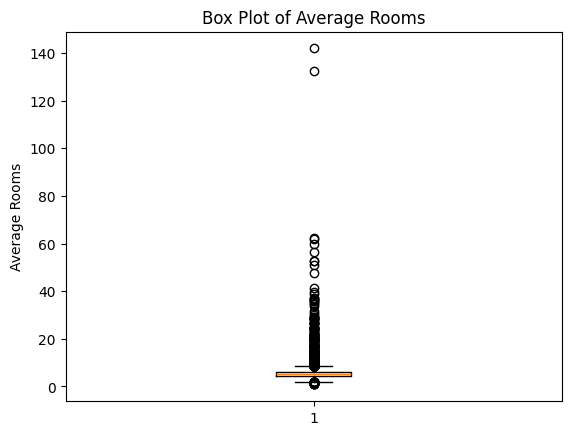

In [8]:
# AveRooms의 Histogram
plt.hist(df["AveRooms"], bins=30)

plt.xlabel("Average Rooms")
plt.ylabel("Frequency")
plt.title("Distribution of Average Rooms")

plt.show()

# 같은 Variable의 Box Plot
plt.figure()
plt.boxplot(df["AveRooms"])

plt.ylabel("Average Rooms")
plt.title("Box Plot of Average Rooms")

plt.show()

## Finding Extreme Values

Visualization을 통해 이상해 보이는 값을 발견했다면 실제 Data에서 그 값을 확인해야 한다.

Plot은 문제를 발견하기 위한 도구이다.

어떤 Sample이 실제로 그런 값을 가지고 있는지는 DataFrame을 이용하여 확인한다.

> Visualization → Suspicion → Data Inspection

In [9]:
# AveRooms가 가장 큰 Sample 10개 확인
extreme_rooms = df.sort_values(
    "AveRooms",
    ascending=False
).head(10)

display(extreme_rooms)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1914,1.8750,33.0,141.909091,25.636364,30.0,2.727273,38.91,-120.10,5.00001
1979,4.6250,34.0,132.533333,34.066667,36.0,2.400000,38.80,-120.08,1.62500
12447,1.6154,17.0,62.422222,14.111111,83.0,1.844444,33.97,-114.49,0.87500
1913,4.0714,19.0,61.812500,11.000000,112.0,2.333333,39.01,-120.06,4.37500
11862,2.6250,25.0,59.875000,15.312500,28.0,1.750000,40.27,-121.25,0.67500
1912,4.9750,16.0,56.269231,10.153846,54.0,2.076923,39.01,-120.16,2.06300
9676,3.2431,14.0,52.848214,11.410714,265.0,2.366071,37.64,-119.02,2.21400
11707,1.1912,22.0,52.690476,8.857143,98.0,2.333333,39.15,-120.06,1.70000
2395,3.8750,23.0,50.837838,10.270270,64.0,1.729730,37.12,-119.34,1.25000
1240,3.1250,11.0,47.515152,11.181818,82.0,2.484848,38.42,-120.19,0.77500


## Bar Plot

Histogram과 Box Plot은 Numerical Variable의 Distribution을 분석하는 데 적합하다.

Category Data에서는 각 Category에 얼마나 많은 Sample이 존재하는지를 비교하는 경우가 많다.

이때 Bar Plot을 사용할 수 있다.

California Housing Data에는 직접적인 Category Variable이 없으므로 `HouseAge`를 몇 개의 Group으로 나누어 보자.

In [10]:
# HouseAge를 Category로 변환
df["AgeGroup"] = pd.cut(
    df["HouseAge"],
    bins=[0, 10, 20, 30, 40, 60],
    labels=["0-10", "11-20", "21-30", "31-40", "41+"]
)

# 각 Category의 Sample 수 계산
age_counts = df["AgeGroup"].value_counts().sort_index()

print(age_counts)

AgeGroup
0-10     1569
11-20    4724
21-30    4852
31-40    5617
41+      3878
Name: count, dtype: int64


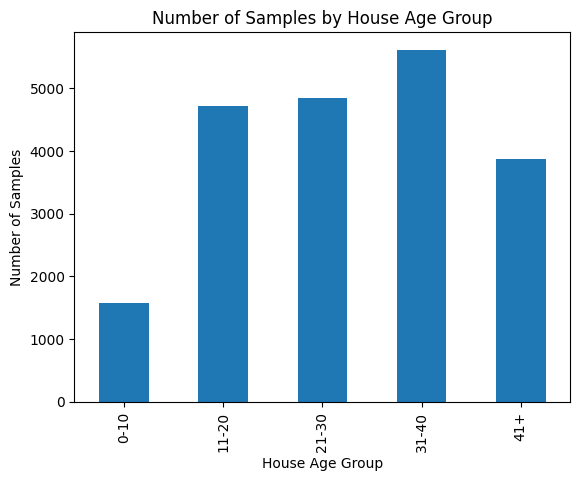

In [11]:
# AgeGroup별 Sample 수를 Bar Plot으로 표현
age_counts.plot(kind="bar")

plt.xlabel("House Age Group")
plt.ylabel("Number of Samples")
plt.title("Number of Samples by House Age Group")

plt.show()

## Histogram vs Bar Plot

Histogram과 Bar Plot은 모양이 비슷하지만 사용하는 목적이 다르다.

Histogram은 연속적인 Numerical Data의 Distribution을 표현한다.

Bar Plot은 서로 구분되는 Category의 값을 비교한다.

예를 들어 `MedInc`의 분포를 보고 싶다면 Histogram을 사용한다.

반면 여러 Region이나 Group의 Sample 수를 비교하고 싶다면 Bar Plot을 사용할 수 있다.

어떤 Plot을 사용할 것인지는 Data Type과 분석 목적에 따라 결정한다.

## Choosing a Visualization

Data를 시각화하기 전에 무엇을 알고 싶은지를 먼저 생각해야 한다.

Numerical Variable의 Distribution을 자세히 보고 싶다면 Histogram을 사용할 수 있다.

Numerical Variable의 중심, 퍼짐, Outlier를 빠르게 확인하고 싶다면 Box Plot을 사용할 수 있다.

Category별 값이나 Sample 수를 비교하고 싶다면 Bar Plot을 사용할 수 있다.

> Question → Data Type → Visualization → Interpretation

좋은 Visualization의 목적은 단순히 예쁜 그림을 만드는 것이 아니다.

Data에서 중요한 특징을 발견하는 것이다.

## Practice

`california_housing.csv`에서 `MedHouseVal`을 분석한다.

다음 순서로 Data를 살펴본다.

- Mean과 Median을 확인한다.
- Histogram을 그린다.
- Box Plot을 그린다.
- Distribution이 대칭적인지 또는 한쪽으로 치우쳐 있는지 관찰한다.
- 매우 크거나 작은 값이 존재하는지 확인한다.

마지막으로 Histogram과 Box Plot에서 발견한 특징이 실제 Data에도 존재하는지 DataFrame을 이용하여 확인한다.

Mean: 2.068558169089147
Median: 1.797


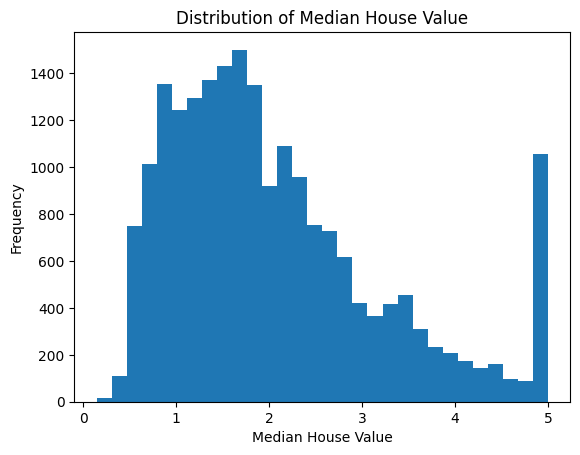

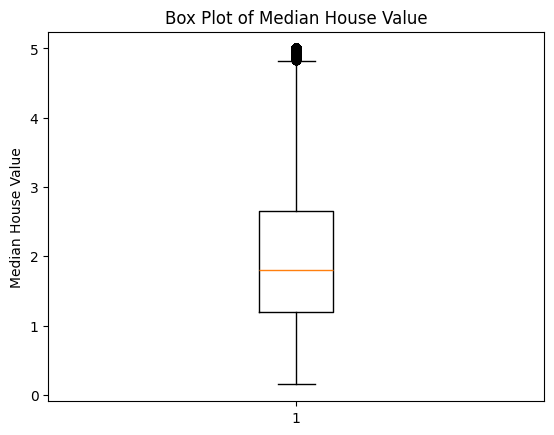

Smallest Values


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19802,0.5360,36.0,12.250000,3.500000,18.0,2.250000,40.31,-123.17,0.14999
2521,1.6607,16.0,6.710526,1.921053,85.0,2.236842,39.71,-122.74,0.14999
2799,2.1000,19.0,3.774390,1.457317,490.0,2.987805,36.40,-117.02,0.14999
9188,4.1932,52.0,3.568889,1.186667,628.0,2.791111,34.24,-117.86,0.14999
5887,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,0.17500


Largest Values


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
5253,13.2935,27.0,7.607143,1.012673,2336.0,2.691244,34.11,-118.49,5.00001
5254,10.7937,29.0,7.471787,1.217868,1500.0,2.351097,34.07,-118.48,5.00001
5255,8.5153,40.0,6.407266,0.925430,1564.0,2.990440,34.07,-118.48,5.00001
5256,12.8665,37.0,7.457565,1.012915,1318.0,2.431734,34.07,-118.48,5.00001
5257,15.0001,42.0,9.229032,1.161290,829.0,2.674194,34.06,-118.49,5.00001


In [13]:
# California Housing Data 읽기
df = pd.read_csv(data_path+"california_housing.csv")

# MedHouseVal의 Mean과 Median 확인
print("Mean:", df["MedHouseVal"].mean())
print("Median:", df["MedHouseVal"].median())

# Histogram
plt.hist(df["MedHouseVal"], bins=30)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")
plt.show()

# Box Plot
plt.boxplot(df["MedHouseVal"])
plt.ylabel("Median House Value")
plt.title("Box Plot of Median House Value")
plt.show()

# 가장 작은 값 5개 확인
print("Smallest Values")
display(
    df.sort_values("MedHouseVal").head(5)
)

# 가장 큰 값 5개 확인
print("Largest Values")
display(
    df.sort_values("MedHouseVal", ascending=False).head(5)
)

### HW_05

`Input/california_housing.csv`의 `AveOccup`를 분석하여 다음 질문에 답하시오.

- `AveOccup`의 Mean과 Median을 각각 적으시오.
- `AveOccup`의 Histogram을 `bins=30`으로 그렸을 때 가장 많은 Data가 분포하는 구간을 적으시오.
- `AveOccup`의 $Q_1$, $Q_3$, IQR을 각각 적으시오.
- IQR 기준으로 계산한 Outlier의 수를 적으시오.
- `AveOccup`의 가장 큰 값과 해당 Row의 `MedHouseVal`을 적으시오.

답만 제출하시오.